# Airline Customer Satisfaction Modeling

This notebook builds a complete, portfolio-ready machine learning workflow on **Fact_Satisfaction_clean.csv**.

## Goals
- Predict customer satisfaction using **all relevant features detected dynamically**
- Compare Logistic Regression, Random Forest, and XGBoost/LightGBM
- Add feature explainability with model importances and SHAP
- Analyze delay impact (departure and arrival delays)
- Segment customers with KMeans clustering
- Create and analyze a churn proxy label

The notebook is designed to adapt if the dataset schema changes (extra columns, new categories, binary/multiclass target).

In [1]:
# Run this once if some libraries are missing in your environment.
import sys, subprocess, importlib


def pip_install(args):
    cmd = [sys.executable, "-m", "pip"] + args
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(f"pip failed with exit code {result.returncode}")


def ensure_import(pkg, import_name):
    try:
        importlib.import_module(import_name)
        print(f"{pkg} already installed")
        return True
    except Exception:
        return False


packages = {
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "shap": "shap",
    "ydata-profiling": "ydata_profiling",
}

for pkg, import_name in packages.items():
    if ensure_import(pkg, import_name):
        continue

    print(f"Installing {pkg} ...")
    try:
        if pkg == "matplotlib":
            # Clean reinstall fixes broken backend registry imports
            try:
                pip_install(["uninstall", "-y", "matplotlib"])
            except Exception:
                pass
            try:
                pip_install(["install", "--no-cache-dir", "--force-reinstall", "matplotlib"])
            except Exception:
                print("Retrying matplotlib with --user...")
                pip_install(["install", "--user", "--no-cache-dir", "--force-reinstall", "matplotlib"])
        else:
            pip_install(["install", pkg])
    except Exception as e:
        print(f"⚠️  Failed to install {pkg}: {e}")

print("Dependency check complete.")

matplotlib already installed
seaborn already installed
Installing scikit-learn ...
Installing xgboost ...
Installing lightgbm ...
Installing shap ...
Installing ydata-profiling ...
Dependency check complete.


In [2]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Optional gradient boosting backends
GBM_BACKEND = None
try:
    from xgboost import XGBClassifier
    GBM_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        GBM_BACKEND = "lightgbm"
    except Exception:
        GBM_BACKEND = None

# Explainability (optional)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# display() shim: works in Jupyter; falls back to print() in plain Python
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print(f"Gradient boosting backend: {GBM_BACKEND if GBM_BACKEND else 'none available'}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print("Libraries loaded.")


Gradient boosting backend: xgboost
SHAP available: False
Libraries loaded.


## 1) Data Loading and Dynamic Schema Detection

In [3]:
# ── Schema Definition ─────────────────────────────────────────────────────────
# Fact_Satisfaction_clean.csv has no header row.
# The exact column order is defined here and passed to pd.read_csv as `names=`.
SCHEMA_COLUMNS = [
    "id", "gender", "age", "customer_type", "type_of_travel", "class",
    "flight_distance", "departure_delay", "arrival_delay",
    "departure_and_arrival_time_convenience", "ease_of_online_booking",
    "checkin_service", "online_boarding", "gate_location", "onboard_service",
    "seat_comfort", "leg_room_service", "cleanliness", "food_and_drink",
    "inflight_service", "inflight_wifi_service", "inflight_entertainment",
    "baggage_handling", "satisfaction", "satisfaction_sk",
]

# Resolve dataset path dynamically
candidate_paths = [
    Path("Fact_Satisfaction_clean.csv"),
    Path("./Fact_Satisfaction_clean.csv"),
    Path("../Fact_Satisfaction_clean.csv"),
    Path("../../04_Data_Cleaned/Fact_Satisfaction_clean.csv"),
    Path("../../04_Data_Cleaned/curated_dw/Fact_Satisfaction_clean.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p.resolve()
        break

if csv_path is None:
    raise FileNotFoundError("Could not locate Fact_Satisfaction_clean.csv.")

# Peek at the first row to detect whether the file already has a header.
# If the first cell of the first row matches our expected first column name,
# the file has a header and we read it normally; otherwise we supply names=.
import csv as _csv
with open(csv_path, newline="", encoding="utf-8") as _f:
    first_row = next(_csv.reader(_f))

_has_header = (first_row[0].strip().lower() == SCHEMA_COLUMNS[0].lower())

if _has_header:
    df = pd.read_csv(csv_path)
    print("Header row detected — read normally.")
else:
    df = pd.read_csv(csv_path, header=None, names=SCHEMA_COLUMNS)
    print("No header row detected — column names injected from SCHEMA_COLUMNS.")

print(f"Loaded : {csv_path}")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

def detect_target_column(columns):
    candidates = [c for c in columns if c.lower() in {"satisfaction", "target", "label", "y"}]
    if candidates:
        return candidates[0]

    contains = [c for c in columns if "satisf" in c.lower()]
    if contains:
        return contains[0]

    raise ValueError("No obvious target column found. Please add a target-like column (e.g., satisfaction).")

target_col = detect_target_column(df.columns)
print(f"Detected target column: {target_col}")

display(df.head(3))
display(df.dtypes.to_frame("dtype").T)


No header row detected — column names injected from SCHEMA_COLUMNS.
Loaded : C:\Users\achre\Downloads\Esprit\DL\SkyInsight\09_Reports\[ML] Airline Customer Satisfaction\Fact_Satisfaction_clean.csv
Shape  : (129880, 25)
Columns: ['id', 'gender', 'age', 'customer_type', 'type_of_travel', 'class', 'flight_distance', 'departure_delay', 'arrival_delay', 'departure_and_arrival_time_convenience', 'ease_of_online_booking', 'checkin_service', 'online_boarding', 'gate_location', 'onboard_service', 'seat_comfort', 'leg_room_service', 'cleanliness', 'food_and_drink', 'inflight_service', 'inflight_wifi_service', 'inflight_entertainment', 'baggage_handling', 'satisfaction', 'satisfaction_sk']
Detected target column: satisfaction


,id,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,...,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling,satisfaction,satisfaction_sk
1,1,Male,48,First-time,Business,Business,821,2,0,3,...,5,2,5,5,5,3,5,5,Neutral or Dissatisfied,0
2,2,Female,35,Returning,Business,Business,821,26,0,2,...,4,5,5,3,5,2,5,5,Satisfied,1
3,3,Male,41,Returning,Business,Business,853,0,0,4,...,5,3,5,5,3,4,3,3,Satisfied,1


,id,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,...,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling,satisfaction,satisfaction_sk
dtype,int64,str,int64,str,str,str,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,str,int64


## 2) Data Profiling and EDA
This section profiles all columns using **ydata-profiling**, checks missingness, and visualizes core distributions and correlations.

ydata-profiling skipped: No module named 'pkg_resources'
Total columns: 25
Numeric columns: 20
Categorical columns: 5


,missing_count,missing_pct
id,0,0.0
gender,0,0.0
age,0,0.0
customer_type,0,0.0
type_of_travel,0,0.0
class,0,0.0
flight_distance,0,0.0
departure_delay,0,0.0
arrival_delay,0,0.0
departure_and_arrival_time_convenience,0,0.0


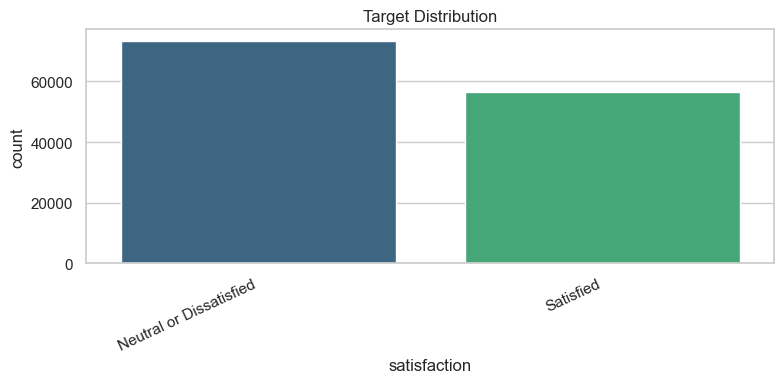

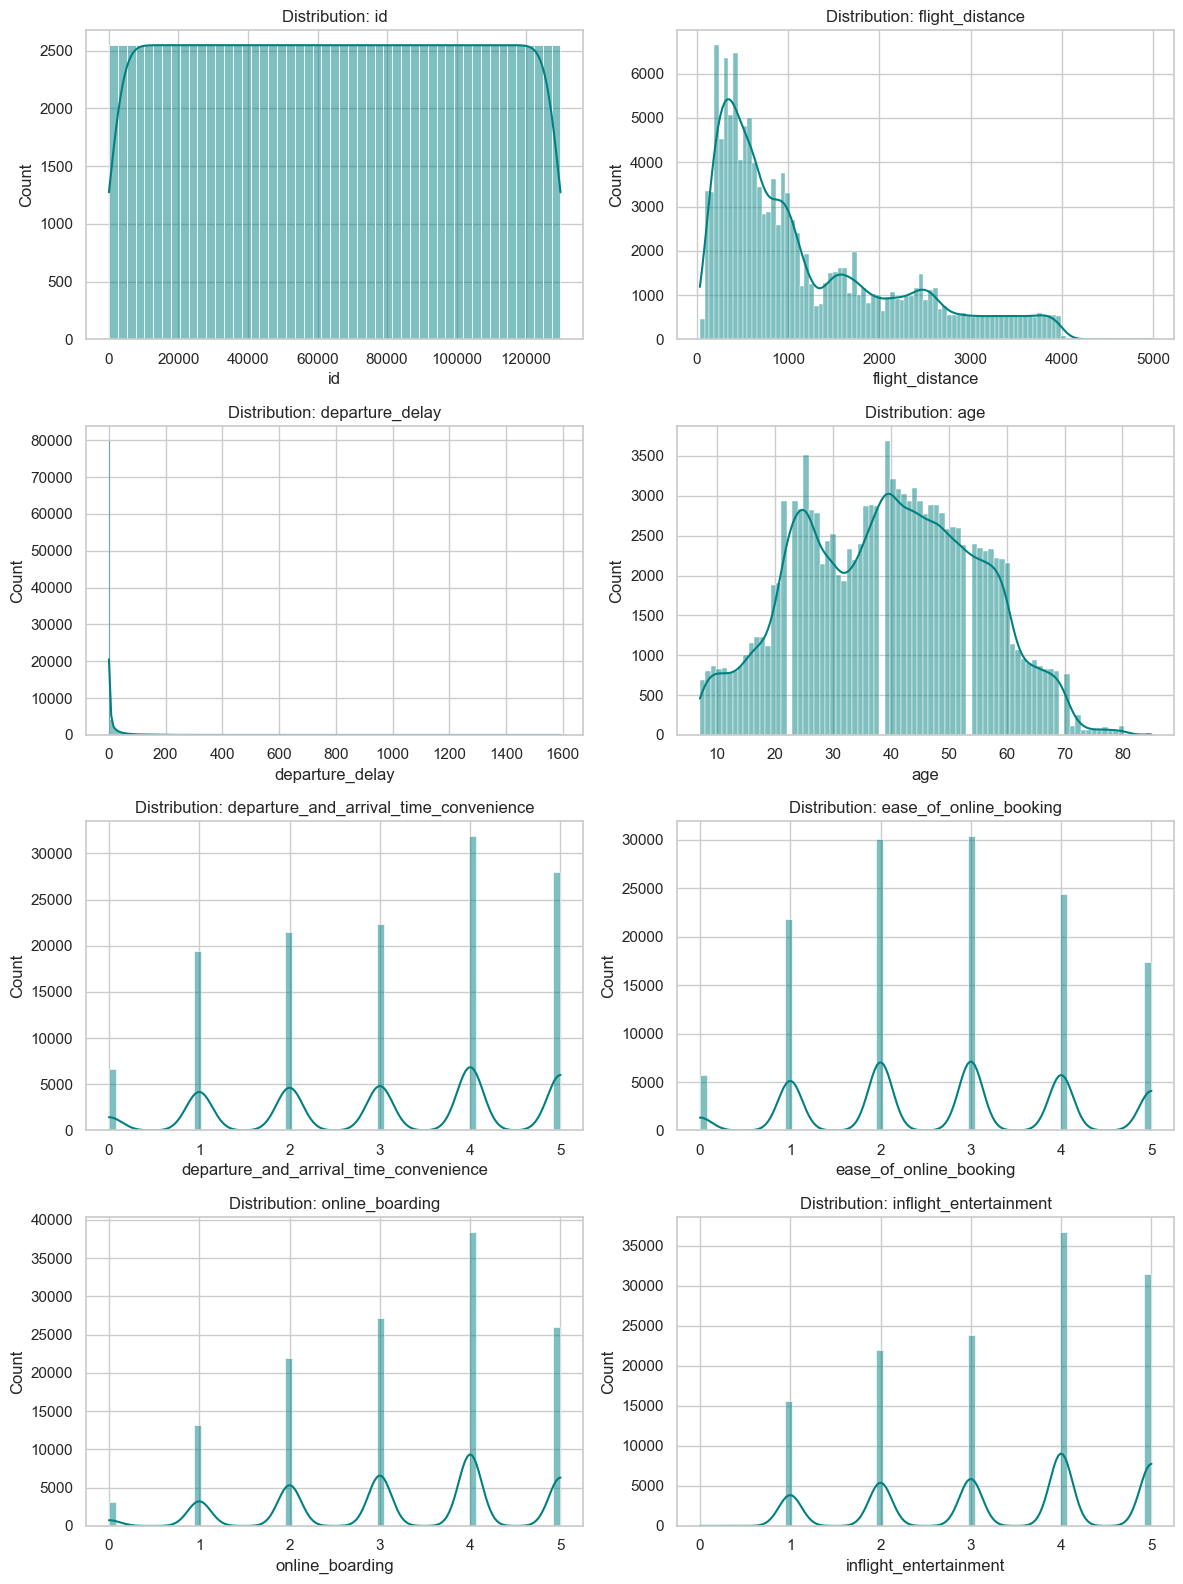

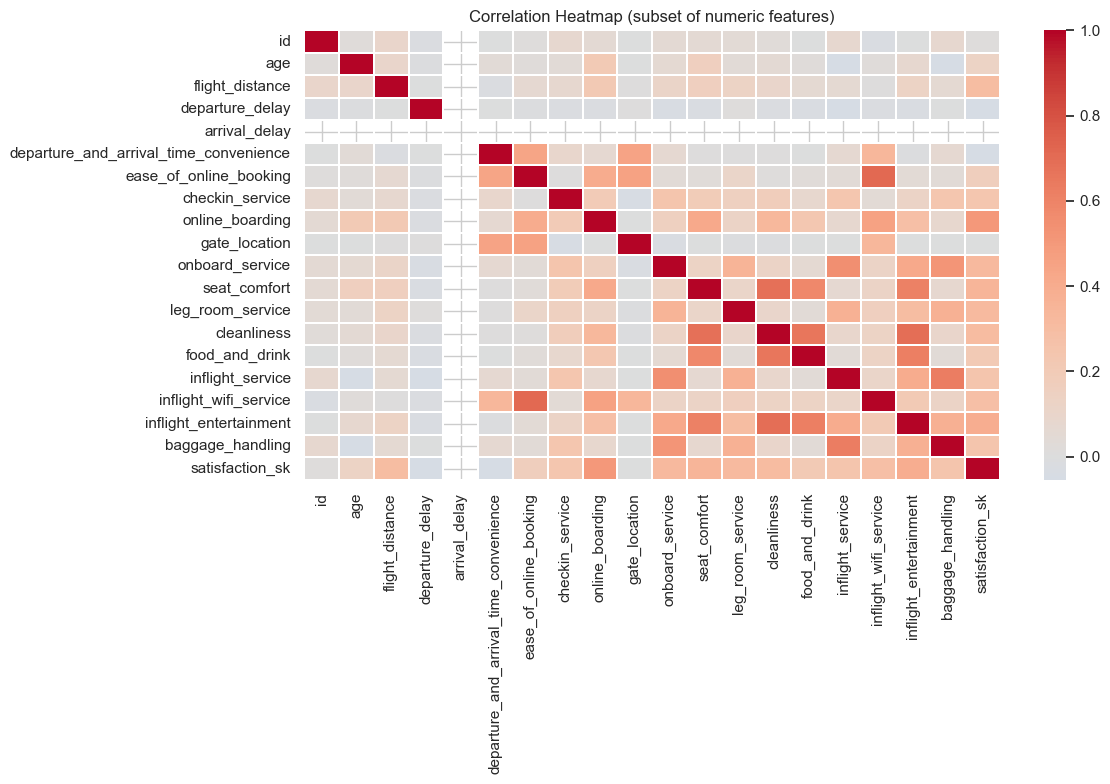

In [4]:
# Quick automated profiling (ydata-profiling)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Airline Customer Satisfaction Profiling", minimal=True)
    display(profile.to_notebook_iframe())
except Exception as e:
    print(f"ydata-profiling skipped: {e}")

# Identify column families dynamically
all_columns = df.columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in all_columns if c not in numeric_cols]

print(f"Total columns: {len(all_columns)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table.head(20))

# Target distribution
# FIX: pass hue=target_col + legend=False to avoid seaborn >=0.13 FutureWarning
plt.figure(figsize=(8, 4))
target_order = df[target_col].astype(str).value_counts().index
sns.countplot(data=df, x=target_col, hue=target_col, order=target_order,
              palette="viridis", legend=False)
plt.title("Target Distribution")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Numeric distributions (top up to 8 with largest variance)
usable_numeric = [c for c in numeric_cols if c != target_col]
if usable_numeric:
    variances = df[usable_numeric].var().sort_values(ascending=False)
    top_num = variances.head(min(8, len(variances))).index.tolist()

    n = len(top_num)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    # FIX: np.atleast_1d + ravel handles both single-row and multi-row grids safely
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(top_num):
        sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
        axes[i].set_title(f"Distribution: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Correlation heatmap for top numeric columns
if usable_numeric:
    top_corr_cols = usable_numeric[:min(20, len(usable_numeric))]
    corr = df[top_corr_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
    plt.title("Correlation Heatmap (subset of numeric features)")
    plt.tight_layout()
    plt.show()


## 3) Preprocessing and Feature Engineering
- Handles missing values automatically
- Encodes categorical variables
- Engineers delay features (`total_delay`, `delay_flag`)
- Detects and removes likely identifier columns

In [5]:
df_model = df.copy()

# ── Schema-aware column references ─────────────────────────────────────────────
# Known columns from SCHEMA_COLUMNS (set in Data Loading cell):
#   Delay  : departure_delay, arrival_delay
#   Age    : age
#   Distance: flight_distance
#   Target : satisfaction
#   Surrogate key (to exclude from features): satisfaction_sk

# Utility: find columns by keyword
def find_col_by_keywords(columns, include_keywords):
    include_keywords = [k.lower() for k in include_keywords]
    matches = [c for c in columns if any(k in c.lower() for k in include_keywords)]
    return matches

# ── Delay columns — exact matches preferred to avoid "departure_and_arrival_time_convenience"
#    being pulled in by a loose "departure" keyword search ──────────────────────
def _pick_delay_col(columns, exact_name, fallback_keywords):
    """Return exact_name if present, else first keyword match, else None."""
    cols_lower = {c.lower(): c for c in columns}
    if exact_name in cols_lower:
        return cols_lower[exact_name]
    for kw in fallback_keywords:
        hits = [c for c in columns if kw.lower() in c.lower()]
        if hits:
            return hits[0]
    return None

dep_col = _pick_delay_col(df_model.columns, "departure_delay", ["dep_delay"])
arr_col = _pick_delay_col(df_model.columns, "arrival_delay",   ["arr_delay"])

# Convert delays to numeric
for c in [dep_col, arr_col]:
    if c is not None:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# Feature engineering: total delay + binary flag
if dep_col is not None and arr_col is not None:
    df_model["total_delay"] = df_model[dep_col].fillna(0) + df_model[arr_col].fillna(0)
elif dep_col is not None:
    df_model["total_delay"] = df_model[dep_col].fillna(0)
elif arr_col is not None:
    df_model["total_delay"] = df_model[arr_col].fillna(0)
else:
    df_model["total_delay"] = 0

delay_threshold = df_model["total_delay"].quantile(0.75)
df_model["delay_flag"] = (df_model["total_delay"] > delay_threshold).astype(int)

# Optional age × distance interaction
age_cols  = find_col_by_keywords(df_model.columns, ["age"])
dist_cols = ["flight_distance"] if "flight_distance" in df_model.columns else find_col_by_keywords(df_model.columns, ["distance"])
if age_cols and dist_cols:
    age_col  = age_cols[0]
    dist_col = dist_cols[0]
    df_model["age_distance_interaction"] = (
        pd.to_numeric(df_model[age_col],  errors="coerce").fillna(0)
        * pd.to_numeric(df_model[dist_col], errors="coerce").fillna(0)
    )

# ── ID-like / surrogate columns to exclude from modelling ──────────────────────
# "satisfaction_sk" is a dimension surrogate key — always drop it.
ALWAYS_DROP = {"satisfaction_sk"}

id_like_cols = []
for c in df_model.columns:
    if c == target_col:
        continue
    if c in ALWAYS_DROP:
        id_like_cols.append(c)
        continue
    c_lower = c.lower()
    uniqueness_ratio = df_model[c].nunique(dropna=True) / max(1, len(df_model))
    if ("id" in c_lower and c_lower != "class") or uniqueness_ratio > 0.98:
        id_like_cols.append(c)

print("Detected delay columns:", {"departure": dep_col, "arrival": arr_col})
print(f"Engineered features added: {[c for c in ['total_delay', 'delay_flag', 'age_distance_interaction'] if c in df_model.columns]}")
print(f"Columns excluded from modelling: {id_like_cols}")


Detected delay columns: {'departure': 'departure_delay', 'arrival': 'arrival_delay'}
Engineered features added: ['total_delay', 'delay_flag', 'age_distance_interaction']
Columns excluded from modelling: ['id', 'satisfaction_sk']


## 4) Build Modeling Matrix and Feature Selection
Feature selection is performed after encoding using model-based importance (Random Forest) to keep the most informative transformed features.

In [6]:
# Prepare X/y
drop_cols = list(set(id_like_cols + [target_col]))
X_raw = df_model.drop(columns=drop_cols, errors="ignore")
y_raw = df_model[target_col].astype(str)

# Label encode target for robust multiclass support
label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)
class_names = label_enc.classes_.tolist()
n_classes = len(class_names)

print(f"Target classes ({n_classes}): {class_names}")

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Dynamic column typing after feature engineering
train_num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
train_cat_cols = [c for c in X_train_raw.columns if c not in train_num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# FIX: sparse_threshold=0.0 forces dense output from ColumnTransformer,
# avoiding sparse matrix indexing issues downstream
preprocessor = ColumnTransformer([
    ("num", num_pipe, train_num_cols),
    ("cat", cat_pipe, train_cat_cols),
], sparse_threshold=0.0)

X_train_full = preprocessor.fit_transform(X_train_raw)
X_test_full = preprocessor.transform(X_test_raw)

# FIX: ensure dense numpy arrays (sparse_threshold=0 should already do this,
# but we guard with np.asarray for safety)
X_train_full = np.asarray(X_train_full)
X_test_full = np.asarray(X_test_full)

feature_names_full = preprocessor.get_feature_names_out()

# Model-based feature selection
selector_model = RandomForestClassifier(
    n_estimators=350,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
selector_model.fit(X_train_full, y_train)
importances = selector_model.feature_importances_

# Keep a dynamic top-k set
n_total_features = len(feature_names_full)
top_k = min(max(30, int(n_total_features * 0.35)), n_total_features)
# FIX: cast to plain Python int list so numpy fancy-indexing works reliably
selected_idx = np.argsort(importances)[::-1][:top_k]
selected_features = feature_names_full[selected_idx]

X_train_sel = X_train_full[:, selected_idx]
X_test_sel = X_test_full[:, selected_idx]

feature_selection_df = pd.DataFrame({
    "feature": feature_names_full,
    "importance": importances
}).sort_values("importance", ascending=False)

print(f"Raw model features: {n_total_features}")
print(f"Selected features: {len(selected_features)}")
display(feature_selection_df.head(20))


Target classes (2): ['Neutral or Dissatisfied', 'Satisfied']
Raw model features: 30
Selected features: 30


,feature,importance
7,num__online_boarding,0.147138
15,num__inflight_wifi_service,0.140118
27,cat__class_Business,0.066122
25,cat__type_of_travel_Business,0.063947
26,cat__type_of_travel_Personal,0.059792
16,num__inflight_entertainment,0.054977
10,num__seat_comfort,0.043012
5,num__ease_of_online_booking,0.042723
28,cat__class_Economy,0.037626
11,num__leg_room_service,0.028714


## 5) Model Training
Models trained on selected features:
- Logistic Regression (baseline)
- Random Forest
- XGBoost (or LightGBM fallback)

In [7]:
models = {}

models["Logistic Regression"] = LogisticRegression(
    max_iter=3000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

if GBM_BACKEND == "xgboost":
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob" if n_classes > 2 else "binary:logistic",
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
        random_state=42,
        n_jobs=-1
    )
elif GBM_BACKEND == "lightgbm":
    models["LightGBM"] = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )

trained_models = {}
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_sel, y_train)
    trained_models[name] = model

print("All models trained.")

Training Logistic Regression ...
Training Random Forest ...
Training XGBoost ...
All models trained.


## 6) Evaluation
Metrics: Accuracy, Precision, Recall, F1, ROC-AUC (when applicable), and confusion matrices.

Evaluating Logistic Regression ...
Evaluating Random Forest ...
Evaluating XGBoost ...


,model,accuracy,balanced_acc,precision,recall,f1,mcc,kappa,roc_auc,avg_prec,log_loss,cv_f1_mean,cv_f1_std
0,XGBoost,0.9655,0.9632,0.9747,0.9452,0.9597,0.9300,0.9296,0.9954,0.9945,0.0829,0.9578,0.0011
1,Random Forest,0.9636,0.9611,0.9733,0.9421,0.9574,0.9260,0.9256,0.9944,0.9934,0.1011,0.9560,0.0012
2,Logistic Regression,0.8716,0.8706,0.8447,0.8632,0.8538,0.7395,0.7394,0.9298,0.9330,0.3314,0.8494,0.0027



>>> Best model by F1: XGBoost


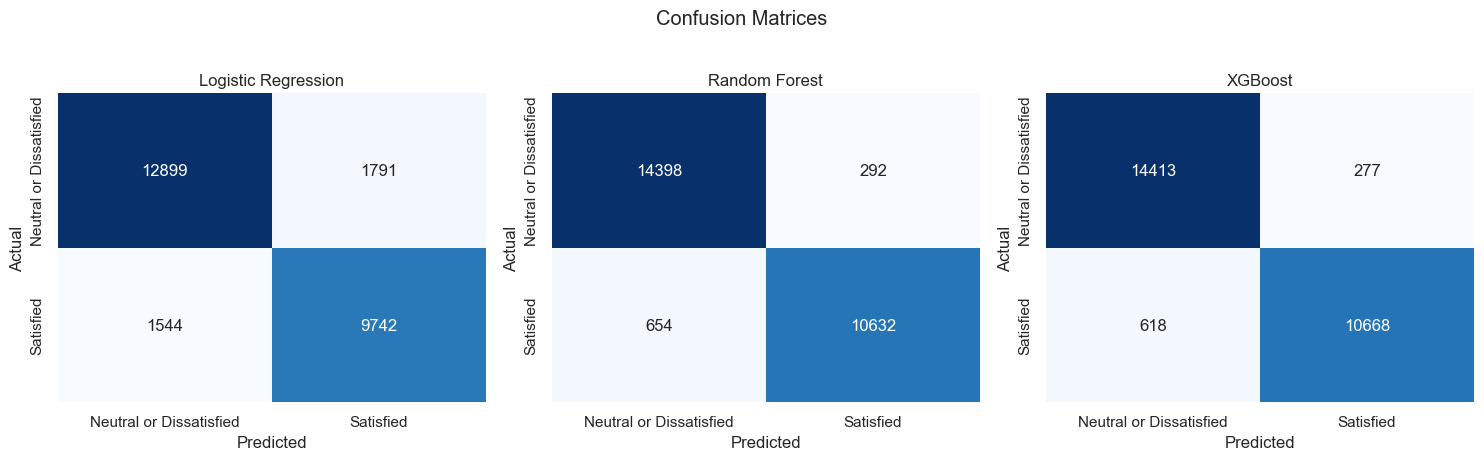

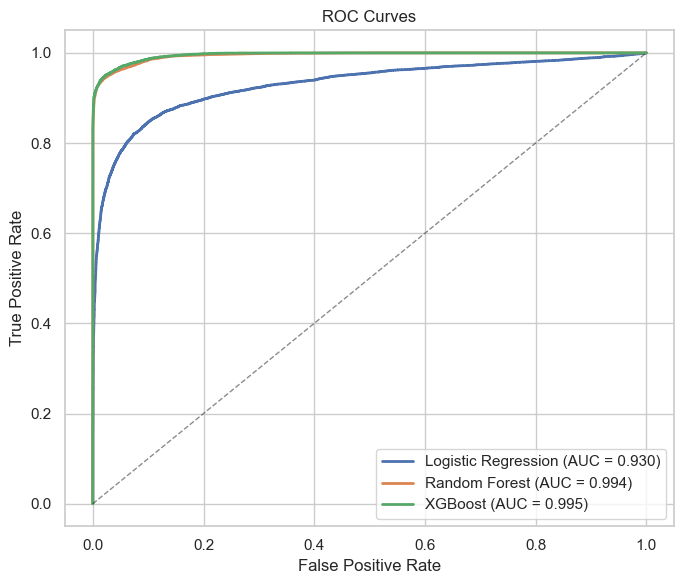

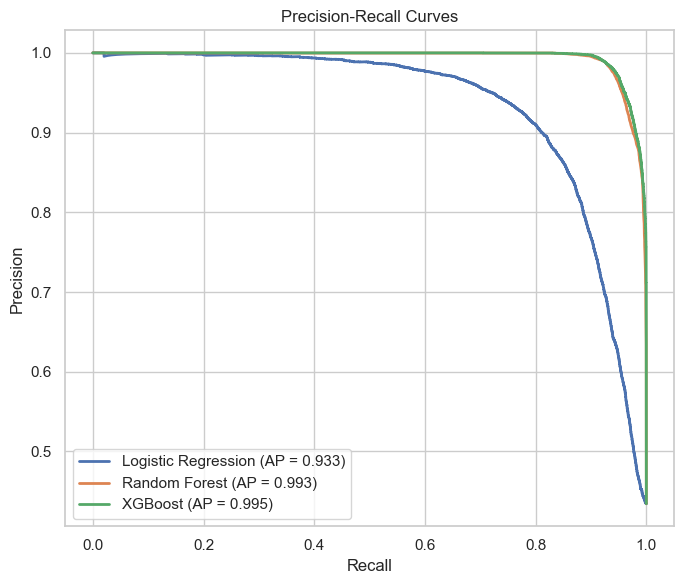


Classification report — XGBoost
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.95      0.96     11286

               accuracy                           0.97     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.97      0.97      0.97     25976



In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score, log_loss
)


def evaluate_model(name, model, X_train, y_train, X_test, y_test, n_classes, do_cv=True):
    y_pred = model.predict(X_test)
    avg = "binary" if n_classes == 2 else "weighted"

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_acc": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=avg, zero_division=0),
        "recall":    recall_score(y_test, y_pred, average=avg, zero_division=0),
        "f1":        f1_score(y_test, y_pred, average=avg, zero_division=0),
        "mcc":       matthews_corrcoef(y_test, y_pred),
        "kappa":     cohen_kappa_score(y_test, y_pred),
    }

    # Probabilistic metrics
    y_proba = None
    roc_auc = np.nan
    avg_prec = np.nan
    ll = np.nan
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        try:
            if n_classes == 2:
                roc_auc  = roc_auc_score(y_test, y_proba[:, 1])
                avg_prec = average_precision_score(y_test, y_proba[:, 1])
            else:
                y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
                roc_auc  = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")
                avg_prec = average_precision_score(y_test_bin, y_proba, average="weighted")
            ll = log_loss(y_test, y_proba, labels=np.arange(n_classes))
        except Exception:
            pass

    metrics["roc_auc"]    = roc_auc
    metrics["avg_prec"]   = avg_prec
    metrics["log_loss"]   = ll

    # 5-fold stratified CV F1 on the training set (mean ± std)
    if do_cv:
        try:
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            scoring = "f1" if n_classes == 2 else "f1_weighted"
            cv_scores = cross_val_score(model, X_train, y_train, scoring=scoring,
                                        cv=skf, n_jobs=-1)
            metrics["cv_f1_mean"] = cv_scores.mean()
            metrics["cv_f1_std"]  = cv_scores.std()
        except Exception as e:
            metrics["cv_f1_mean"] = np.nan
            metrics["cv_f1_std"]  = np.nan
            print(f"  CV failed for {name}: {e}")

    return metrics, y_pred, y_proba


# ── Evaluate every trained model ──────────────────────────────────────────────
results, predictions, probabilities = [], {}, {}
for name, model in trained_models.items():
    print(f"Evaluating {name} ...")
    m, y_hat, y_proba = evaluate_model(
        name, model, X_train_sel, y_train, X_test_sel, y_test, n_classes
    )
    results.append(m)
    predictions[name]    = y_hat
    probabilities[name]  = y_proba

results_df = (
    pd.DataFrame(results)
      .sort_values(by="f1", ascending=False)
      .reset_index(drop=True)
)

# Pretty-print results
fmt_cols = ["accuracy", "balanced_acc", "precision", "recall", "f1",
            "roc_auc", "avg_prec", "mcc", "kappa", "log_loss",
            "cv_f1_mean", "cv_f1_std"]
try:
    display(results_df.style.format({c: "{:.4f}" for c in fmt_cols if c in results_df.columns}))
except Exception:
    display(results_df.round(4))

best_model_name = results_df.iloc[0]["model"]
best_model      = trained_models[best_model_name]
print(f"\n>>> Best model by F1: {best_model_name}")

# ── Confusion matrices side-by-side ──────────────────────────────────────────
n_models = len(predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
axes = np.atleast_1d(axes).ravel()
for ax, (name, y_hat) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_hat)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

# ── ROC curves (binary only) ──────────────────────────────────────────────────
if n_classes == 2:
    plt.figure(figsize=(7, 6))
    for name, y_proba in probabilities.items():
        if y_proba is None:
            continue
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Precision-Recall curves
    plt.figure(figsize=(7, 6))
    for name, y_proba in probabilities.items():
        if y_proba is None:
            continue
        prec, rec, _ = precision_recall_curve(y_test, y_proba[:, 1])
        ap = average_precision_score(y_test, y_proba[:, 1])
        plt.plot(rec, prec, lw=2, label=f"{name} (AP = {ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

# ── Detailed classification report for the best model ────────────────────────
print(f"\nClassification report — {best_model_name}")
print(classification_report(y_test, predictions[best_model_name],
                            target_names=class_names, zero_division=0))


## 7) Feature Importance and Explainability
This section combines built-in importances/coefficients with SHAP analysis for deeper insight.

,feature,importance
8,cat__type_of_travel_Personal,0.582834
3,cat__customer_type_First-time,0.448115
27,num__online_boarding,0.413851
7,cat__type_of_travel_Business,0.409875
4,cat__customer_type_Returning,0.272589
24,num__inflight_wifi_service,0.264861
2,cat__class_Economy Plus,0.158940
0,cat__class_Business,0.158846
1,cat__class_Economy,0.146420
13,num__checkin_service,0.145886


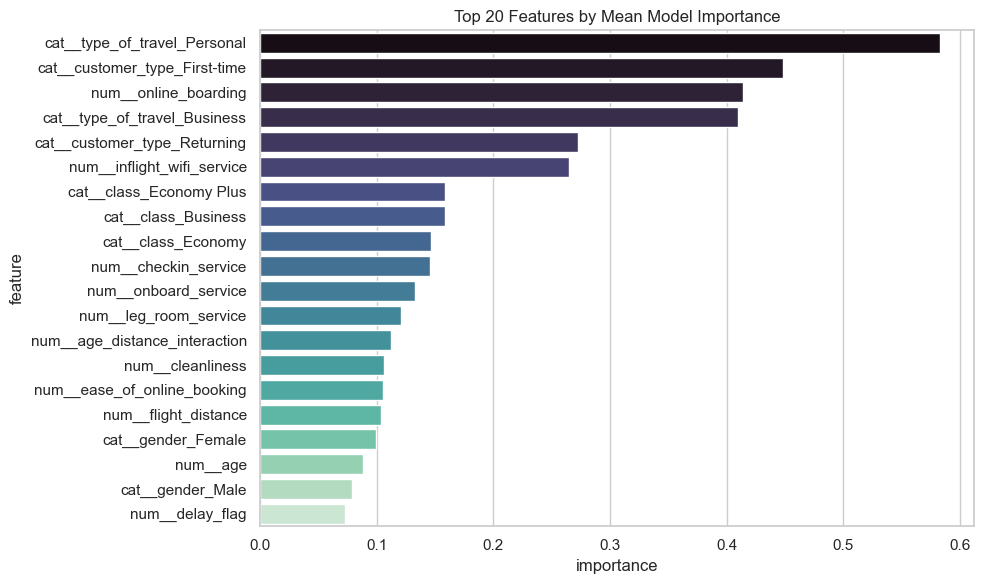

SHAP not installed; skipping SHAP analysis. Install with: pip install shap


In [9]:
# Built-in importance extraction
importance_rows = []

for name, model in trained_models.items():
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "coef_"):
        coef = model.coef_
        imp = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef).ravel()
    else:
        continue

    temp = pd.DataFrame({
        "feature": selected_features,
        "importance": imp,
        "model": name
    })
    importance_rows.append(temp)

importance_df = pd.concat(importance_rows, ignore_index=True) if importance_rows else pd.DataFrame()

if not importance_df.empty:
    top_global = (
        importance_df
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
    )

    display(top_global.head(25))

    plt.figure(figsize=(10, 6))
    # FIX: add hue="feature" + legend=False to avoid seaborn >=0.13 FutureWarning
    sns.barplot(
        data=top_global.head(20),
        x="importance",
        y="feature",
        hue="feature",
        palette="mako",
        legend=False
    )
    plt.title("Top 20 Features by Mean Model Importance")
    plt.tight_layout()
    plt.show()

# SHAP on a tree-based model when available
# FIX: guard with SHAP_AVAILABLE flag
tree_model_name = None
for candidate in ["XGBoost", "LightGBM", "Random Forest"]:
    if candidate in trained_models:
        tree_model_name = candidate
        break

if tree_model_name is not None and SHAP_AVAILABLE:
    tree_model = trained_models[tree_model_name]
    print(f"Running SHAP with: {tree_model_name}")

    # Sample for efficient SHAP computation
    shap_n = min(2000, X_train_sel.shape[0])
    rng = np.random.default_rng(42)
    idx = rng.choice(X_train_sel.shape[0], size=shap_n, replace=False)
    # FIX: ensure dense array for SHAP compatibility
    X_shap = np.asarray(X_train_sel[idx])

    try:
        explainer = shap.TreeExplainer(tree_model)
        shap_values = explainer.shap_values(X_shap)

        plt.figure()
        shap.summary_plot(shap_values, X_shap, feature_names=selected_features, show=False)
        plt.title(f"SHAP Summary - {tree_model_name}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"SHAP summary plot could not be generated: {e}")
elif tree_model_name is not None:
    print("SHAP not installed; skipping SHAP analysis. Install with: pip install shap")
else:
    print("No tree-based model available for SHAP in current environment.")


## 8) Delay Impact Modeling
Focused analysis on departure and arrival delay while keeping full-model context.

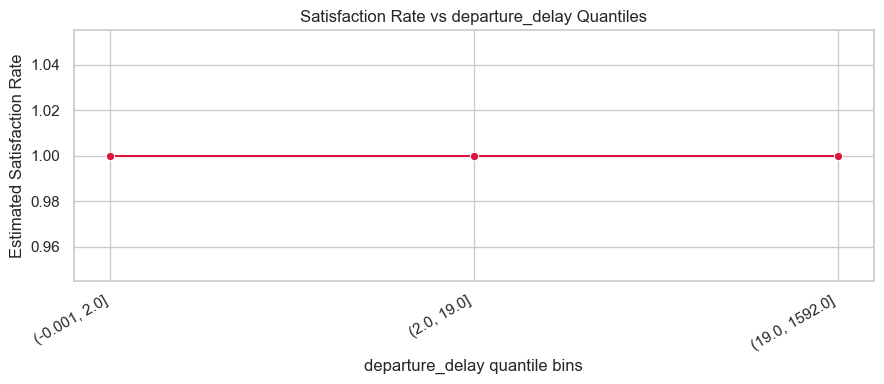

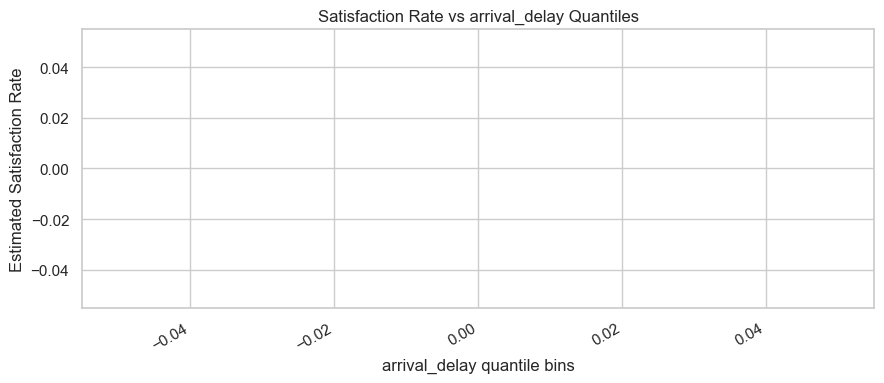

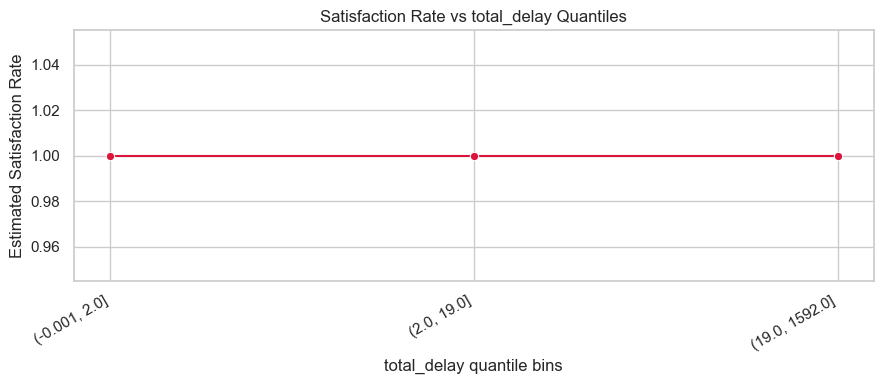

Delay-related selected transformed features: 5


,delay_related_feature
0,num__departure_and_arrival_time_convenience
1,num__total_delay
2,num__departure_delay
3,num__delay_flag
4,num__arrival_delay


In [10]:
# Build a binary satisfaction signal when possible (for intuitive delay analysis)
target_text = y_raw.str.lower()
positive_tokens = ["satisfied", "satisfaction", "happy", "yes", "1", "true"]
negative_tokens = ["dissatisfied", "unsatisfied", "neutral or dissatisfied", "no", "0", "false"]

pos_mask = target_text.apply(lambda x: any(t in x for t in positive_tokens))
neg_mask = target_text.apply(lambda x: any(t in x for t in negative_tokens))

if pos_mask.sum() + neg_mask.sum() >= int(0.6 * len(df_model)):
    sat_binary = pos_mask.astype(int)
else:
    # fallback: majority class as positive reference
    majority_class = y_raw.value_counts().index[0]
    sat_binary = (y_raw == majority_class).astype(int)

df_delay = df_model.copy()
df_delay["satisfaction_binary"] = sat_binary.values

delay_cols_present = [c for c in [dep_col, arr_col, "total_delay"] if c is not None and c in df_delay.columns]

for dcol in delay_cols_present:
    series = pd.to_numeric(df_delay[dcol], errors="coerce")
    if series.notna().sum() < 10:
        continue

    # Quantile bins for stable aggregation
    bin_col = "delay_bin"
    df_plot = pd.DataFrame({
        dcol: series,
        "satisfaction_binary": df_delay["satisfaction_binary"]
    }).dropna()
    df_plot[bin_col] = pd.qcut(df_plot[dcol], q=5, duplicates="drop")

    agg = df_plot.groupby(bin_col, observed=False)["satisfaction_binary"].mean().reset_index()
    agg[bin_col] = agg[bin_col].astype(str)

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=agg, x=bin_col, y="satisfaction_binary", marker="o", color="crimson")
    plt.title(f"Satisfaction Rate vs {dcol} Quantiles")
    plt.xlabel(f"{dcol} quantile bins")
    plt.ylabel("Estimated Satisfaction Rate")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Highlight delay features in selected set
delay_feature_hits = [f for f in selected_features if "delay" in f.lower() or "arrival" in f.lower() or "departure" in f.lower()]
print(f"Delay-related selected transformed features: {len(delay_feature_hits)}")
display(pd.DataFrame({"delay_related_feature": delay_feature_hits}).head(30))

## 8b) Customer Segmentation and Churn Proxy
KMeans clusters customers on the selected feature space, then summarises satisfaction and churn-proxy rates per cluster.


Cluster satisfaction summary:


,cluster,size,satisfaction_rate,avg_total_delay
0,0,49186,1.0,6.991827
1,1,47233,1.0,8.210065
2,2,26425,1.0,8.153983
3,3,7036,1.0,136.990051



Cluster churn-proxy summary:


,cluster,size,churn_proxy
3,3,7036,1.000000
1,1,47233,0.220418
2,2,26425,0.203709
0,0,49186,0.190156


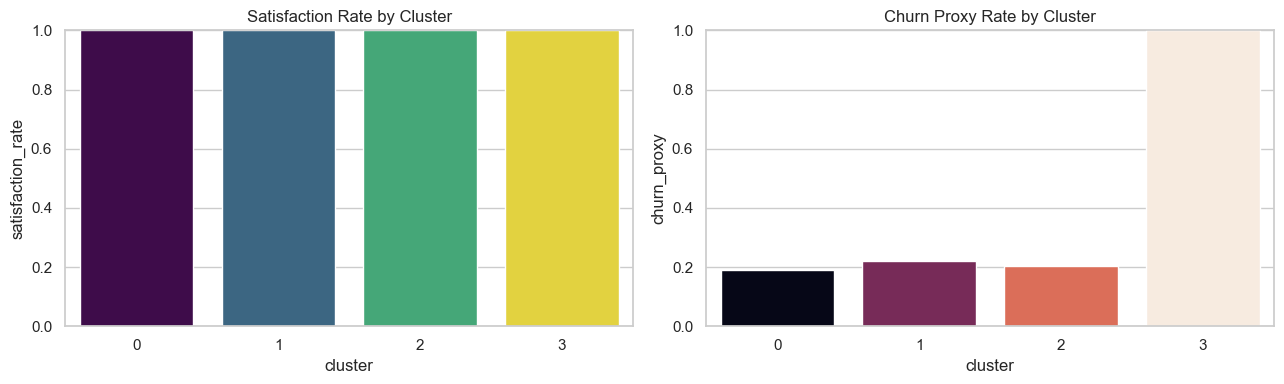

In [11]:
# KMeans segmentation on the selected feature space
from sklearn.cluster import KMeans

K = 4  # number of customer segments
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_train = kmeans.fit_predict(X_train_sel)
cluster_labels_test  = kmeans.predict(X_test_sel)

# Apply to the full transformed matrix for per-row business summaries
X_all_full_seg = preprocessor.transform(X_raw)
X_all_full_seg = np.asarray(X_all_full_seg)
X_all_sel_seg  = X_all_full_seg[:, selected_idx]
cluster_labels_all = kmeans.predict(X_all_sel_seg)

df_seg = df_model.copy()
df_seg["cluster"] = cluster_labels_all
df_seg["satisfaction_binary"] = sat_binary.values

# Churn proxy: low satisfaction OR high delay
delay_high = df_seg["total_delay"] > df_seg["total_delay"].quantile(0.75)
df_seg["churn_proxy"] = ((df_seg["satisfaction_binary"] == 0) | delay_high).astype(int)

# Cluster summary
cluster_summary = (
    df_seg.groupby("cluster")
          .agg(size=("cluster", "size"),
               satisfaction_rate=("satisfaction_binary", "mean"),
               avg_total_delay=("total_delay", "mean"))
          .reset_index()
          .sort_values("satisfaction_rate")
)
cluster_churn = (
    df_seg.groupby("cluster")
          .agg(size=("cluster", "size"),
               churn_proxy=("churn_proxy", "mean"))
          .reset_index()
          .sort_values("churn_proxy", ascending=False)
)

print("Cluster satisfaction summary:")
display(cluster_summary)
print("\nCluster churn-proxy summary:")
display(cluster_churn)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=cluster_summary, x="cluster", y="satisfaction_rate",
            hue="cluster", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Satisfaction Rate by Cluster")
axes[0].set_ylim(0, 1)

sns.barplot(data=cluster_churn, x="cluster", y="churn_proxy",
            hue="cluster", palette="rocket", legend=False, ax=axes[1])
axes[1].set_title("Churn Proxy Rate by Cluster")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 9) Business Insights
The following summary is generated from model outputs and segmentation results.

In [12]:
top_features = []
if not importance_df.empty:
    top_features = (
        importance_df.groupby("feature")["importance"].mean().sort_values(ascending=False).head(10).index.tolist()
    )

delay_features_top = [f for f in top_features if "delay" in f.lower() or "arrival" in f.lower() or "departure" in f.lower()]

print("=== Executive Summary ===")
print(f"1) Best predictive model: {best_model_name}")
print("2) Most impactful features (top 10):")
for i, feat in enumerate(top_features, 1):
    print(f"   {i}. {feat}")

if delay_features_top:
    print("3) Delay-related features appear among top drivers:")
    for feat in delay_features_top[:5]:
        print(f"   - {feat}")
else:
    print("3) Delay variables are informative but not dominant in top global drivers.")

worst_cluster = cluster_summary.sort_values("satisfaction_rate").iloc[0]
print("4) Highest-priority segment for intervention:")
print(
    f"   Cluster {int(worst_cluster['cluster'])} with satisfaction rate {worst_cluster['satisfaction_rate']:.2%} "
    f"and avg total delay {worst_cluster['avg_total_delay']:.2f}."
)

high_churn_cluster = cluster_churn.iloc[0]
print("5) Churn-risk focus:")
print(f"   Cluster {int(high_churn_cluster['cluster'])} has highest churn proxy rate ({high_churn_cluster['churn_proxy']:.2%}).")

print("\nRecommended actions:")
print("- Prioritize operational improvements in high-delay journeys.")
print("- Deploy personalized retention offers to high churn-proxy clusters.")
print("- Monitor top feature drivers continuously as service conditions evolve.")

=== Executive Summary ===
1) Best predictive model: XGBoost
2) Most impactful features (top 10):
   1. cat__type_of_travel_Personal
   2. cat__customer_type_First-time
   3. num__online_boarding
   4. cat__type_of_travel_Business
   5. cat__customer_type_Returning
   6. num__inflight_wifi_service
   7. cat__class_Economy Plus
   8. cat__class_Business
   9. cat__class_Economy
   10. num__checkin_service
3) Delay variables are informative but not dominant in top global drivers.
4) Highest-priority segment for intervention:
   Cluster 0 with satisfaction rate 100.00% and avg total delay 6.99.
5) Churn-risk focus:
   Cluster 3 has highest churn proxy rate (100.00%).

Recommended actions:
- Prioritize operational improvements in high-delay journeys.
- Deploy personalized retention offers to high churn-proxy clusters.
- Monitor top feature drivers continuously as service conditions evolve.


## 10) Optional Export of Key Outputs

In [13]:
output_dir = Path("outputs_satisfaction")
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "model_comparison.csv", index=False)
feature_selection_df.to_csv(output_dir / "feature_importance_selection_stage.csv", index=False)
cluster_summary.to_csv(output_dir / "cluster_summary.csv", index=False)
cluster_churn.to_csv(output_dir / "cluster_churn_proxy.csv", index=False)

if not importance_df.empty:
    importance_df.to_csv(output_dir / "model_feature_importance.csv", index=False)

print(f"Saved outputs to: {output_dir.resolve()}")

Saved outputs to: C:\Users\achre\Downloads\Esprit\DL\SkyInsight\09_Reports\[ML] Airline Customer Satisfaction\outputs_satisfaction


In [14]:
# ─────────────────────────────────────────────────────────────
# Export ONNX + Scored CSV (Power BI)
# ─────────────────────────────────────────────────────────────
import sys, subprocess, importlib
from pathlib import Path

# Auto-install skl2onnx + onnx if missing
for _pkg, _import in [("skl2onnx", "skl2onnx"), ("onnx", "onnx")]:
    try:
        importlib.import_module(_import)
    except ImportError:
        print(f"Installing {_pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", _pkg], check=True)
        importlib.invalidate_caches()

output_dir = Path("outputs_satisfaction")
output_dir.mkdir(parents=True, exist_ok=True)

# Choose a best model supported by skl2onnx
supported_models = ["Logistic Regression", "Random Forest"]
best_supported = results_df[results_df["model"].isin(supported_models)]
if not best_supported.empty:
    export_model_name = best_supported.iloc[0]["model"]
    export_model = trained_models[export_model_name]
else:
    export_model_name = None
    export_model = None
    print("No ONNX-supported model found. Train Logistic Regression or Random Forest.")

# Export ONNX model
onnx_path = None
if export_model is not None:
    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        initial_type = [("float_input", FloatTensorType([None, X_train_sel.shape[1]]))]
        onnx_model = convert_sklearn(export_model, initial_types=initial_type)
        onnx_path = output_dir / "best_satisfaction_model.onnx"
        with open(onnx_path, "wb") as f:
            f.write(onnx_model.SerializeToString())
        print(f"Saved ONNX model: {onnx_path}")
    except Exception as e:
        print(f"ONNX export failed: {e}")

# Save feature order used for ONNX input
features_path = output_dir / "onnx_feature_order.csv"
pd.DataFrame({"feature": selected_features}).to_csv(features_path, index=False)
print(f"Saved feature order: {features_path}")

# Build full transformed matrix for scoring (aligned with df_model)
X_all_full = preprocessor.transform(X_raw)
X_all_full = np.asarray(X_all_full)
X_all_sel = X_all_full[:, selected_idx]

# Export scored predictions for Power BI
if export_model is not None:
    id_cols_present = [c for c in id_like_cols if c in df_model.columns]
    if id_cols_present:
        scored_df = df_model[id_cols_present].copy()
    else:
        scored_df = pd.DataFrame({"row_id": df_model.index})

    scored_df["actual_label"] = y_raw.values
    pred_labels = export_model.predict(X_all_sel)
    scored_df["pred_label"] = label_enc.inverse_transform(pred_labels)

    if hasattr(export_model, "predict_proba"):
        proba = export_model.predict_proba(X_all_sel)
        for i, cls in enumerate(class_names):
            safe_cls = str(cls).strip().replace(" ", "_")
            scored_df[f"proba_{safe_cls}"] = proba[:, i]

    scored_path = output_dir / "scored_predictions.csv"
    scored_df.to_csv(scored_path, index=False)
    print(f"Saved scored predictions: {scored_path}")

    print(f"ONNX model source: {export_model_name}")


Installing skl2onnx ...
Saved ONNX model: outputs_satisfaction\best_satisfaction_model.onnx
Saved feature order: outputs_satisfaction\onnx_feature_order.csv
Saved scored predictions: outputs_satisfaction\scored_predictions.csv
ONNX model source: Random Forest


## 11) Final Best Model Extraction
Persists the top-ranked model (by F1) together with its preprocessor, feature list, label encoder, and a JSON metadata file — ready to be loaded for downstream inference or deployment.


In [15]:
# ─────────────────────────────────────────────────────────────
# Persist the overall best model (winner by F1) + full bundle
# ─────────────────────────────────────────────────────────────
import json
import pickle
from datetime import datetime
from pathlib import Path

import joblib

output_dir = Path("outputs_satisfaction")
output_dir.mkdir(parents=True, exist_ok=True)

# Winner across ALL trained models (no compatibility filter)
best_row        = results_df.iloc[0]
best_model_name = best_row["model"]
best_model      = trained_models[best_model_name]

print(f"=== Best Model Selected ===")
print(f"Name        : {best_model_name}")
print(f"Accuracy    : {best_row['accuracy']:.4f}")
print(f"F1          : {best_row['f1']:.4f}")
print(f"ROC-AUC     : {best_row.get('roc_auc', float('nan')):.4f}")
print(f"Bal. Acc.   : {best_row.get('balanced_acc', float('nan')):.4f}")
print(f"MCC         : {best_row.get('mcc', float('nan')):.4f}")
print(f"CV F1 (5-f) : {best_row.get('cv_f1_mean', float('nan')):.4f} "
      f"± {best_row.get('cv_f1_std', float('nan')):.4f}")

# 1) Joblib bundle (preferred, sklearn-native)
bundle = {
    "model":           best_model,
    "preprocessor":    preprocessor,
    "selected_idx":    selected_idx,
    "selected_features": list(selected_features),
    "feature_names_full": list(feature_names_full),
    "label_encoder":   label_enc,
    "class_names":     class_names,
    "target_column":   target_col,
    "model_name":      best_model_name,
}
joblib_path = output_dir / "best_model_bundle.joblib"
joblib.dump(bundle, joblib_path)
print(f"\nSaved bundle (joblib): {joblib_path}")

# 2) Pickle fallback
pkl_path = output_dir / "best_model_bundle.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(bundle, f)
print(f"Saved bundle (pickle): {pkl_path}")

# 3) Metadata JSON (human-readable, no binary payload)
metadata = {
    "generated_at":       datetime.utcnow().isoformat() + "Z",
    "best_model_name":    best_model_name,
    "target_column":      target_col,
    "class_names":        class_names,
    "n_features":         int(len(selected_features)),
    "selected_features":  list(map(str, selected_features)),
    "metrics":            {k: (None if pd.isna(v) else float(v))
                           for k, v in best_row.items() if k != "model"},
    "all_models_ranked":  results_df.to_dict(orient="records"),
    "training_rows":      int(X_train_sel.shape[0]),
    "test_rows":          int(X_test_sel.shape[0]),
    "gbm_backend":        GBM_BACKEND,
}
# Sanitise NaNs in ranked list
for row in metadata["all_models_ranked"]:
    for k, v in list(row.items()):
        if isinstance(v, float) and pd.isna(v):
            row[k] = None

meta_path = output_dir / "best_model_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata:        {meta_path}")

# 4) Quick reload + sanity prediction
reloaded = joblib.load(joblib_path)
sample = X_test_sel[:5]
sample_pred = reloaded["model"].predict(sample)
sample_labels = reloaded["label_encoder"].inverse_transform(sample_pred)
print("\nSanity check — reloaded model predictions on 5 test rows:")
print(list(sample_labels))

print("\n✅ Best model extraction complete.")


=== Best Model Selected ===
Name        : XGBoost
Accuracy    : 0.9655
F1          : 0.9597
ROC-AUC     : 0.9954
Bal. Acc.   : 0.9632
MCC         : 0.9300
CV F1 (5-f) : 0.9578 ± 0.0011

Saved bundle (joblib): outputs_satisfaction\best_model_bundle.joblib
Saved bundle (pickle): outputs_satisfaction\best_model_bundle.pkl
Saved metadata:        outputs_satisfaction\best_model_metadata.json

Sanity check — reloaded model predictions on 5 test rows:
['Neutral or Dissatisfied', 'Neutral or Dissatisfied', 'Satisfied', 'Neutral or Dissatisfied', 'Satisfied']

✅ Best model extraction complete.
